# 10장 실습 ③ — 시드만 바꾼다

**PyTorch 판**

여기서 진짜 문제가 드러납니다. **같은 코드입니다. 시드만 다릅니다.**

## 10.0 준비

In [1]:
try:
    import dlbook
except ImportError:
    !pip install -q "dlbook @ git+https://github.com/dhrim/deep-learning-in-one-semester.git"
    import dlbook

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import dlbook
from dlbook import data, metrics, plot

dlbook.set_seed(42)
plot.use_korean()
print(dlbook.versions())

{'python': '3.12.3', 'numpy': '2.1.3', 'keras': '-', 'tensorflow': '-', 'torch': '2.14.0', 'keras_backend': '-'}


## 10.1 실험대 — 표시된 자리를 기억하기

순차열은 대부분 잡음입니다. **한 자리**에만 신호가 있고, 두 번째 채널이
그 자리를 표시합니다. **그 신호의 부호**를 맞힙니다.

표시된 자리가 앞쪽이므로, 그 값을 **끝까지 여러 걸음 들고 가야** 합니다.

구분            개수  입력 shape
train       2800  (80, 2)
val          600  (80, 2)
test         600  (80, 2)


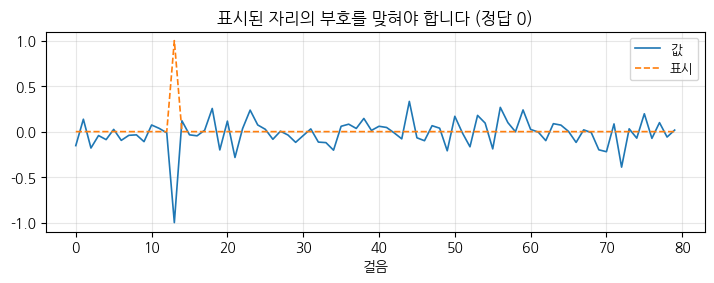

In [3]:
# 표시된 자리의 값을 끝까지 들고 가야 풀리는 문제.
x, y = data.memory_task(4000, length=80, seed=42)
sl = data.split(x, y, val_ratio=0.15, test_ratio=0.15, seed=42)
print(sl.summary())

fig, ax = plt.subplots(figsize=(8.5, 2.6))
ax.plot(x[0, :, 0], lw=1.2, label="값")
ax.plot(x[0, :, 1], lw=1.2, ls="--", label="표시")
ax.set_xlabel("걸음"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_title(f"표시된 자리의 부호를 맞혀야 합니다 (정답 {y[0]})")
plt.show()

## 10.2 학습 함수 — 여기만 판마다 다릅니다

**PyTorch 판에 `Recurrent` 래퍼가 하나 더 있는 것**에 주목하십시오.
PyTorch의 순환 층은 (출력 전체, 마지막 상태)를 돌려주므로,
Keras의 기본 동작(마지막 것만)과 맞추려면 감싸야 합니다.

In [4]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"

class Recurrent(nn.Module):
    """마지막 걸음의 상태만 꺼내 쓰는 순환 층.

    PyTorch의 RNN/LSTM/GRU는 (출력 전체, 마지막 상태)를 돌려준다.
    Keras의 기본 동작(마지막 것만)과 맞추려면 이렇게 감싼다.
    """
    def __init__(self, kind, n_in, units, n_out):
        super().__init__()
        C = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[kind]
        self.rnn = C(n_in, units, batch_first=True)
        self.head = nn.Linear(units, n_out)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1])              # 마지막 걸음만

def _train(model, xa, ya, xb, yb, loss_fn, lr, epochs, bs=64, cls=True):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    yt = torch.tensor(ya, dtype=torch.long if cls else torch.float32)
    if not cls:
        yt = yt.view(-1, 1)
    dl = DataLoader(TensorDataset(torch.tensor(xa, dtype=torch.float32), yt),
                    batch_size=bs, shuffle=True)
    for _ in range(dlbook.smoke.epochs(epochs)):
        model.train()
        for xx, yy in dl:
            xx, yy = xx.to(device), yy.to(device)
            opt.zero_grad(); loss_fn(model(xx), yy).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        out = model(torch.tensor(xb, dtype=torch.float32).to(device)).cpu().numpy()
    return model, out

def train_seq(kind, sp, length, lr=0.001, seed=42, epochs=25):
    """분류: 표시된 자리의 부호 맞히기. (시험 정확도)

    이 함수 하나만 판마다 다르다. 아래의 모든 실험 셀은 세 판이 같다.
    """
    dlbook.set_seed(seed)
    if kind == "dnn":
        model = nn.Sequential(nn.Flatten(), nn.Linear(length * 2, 64),
                              nn.ReLU(), nn.Linear(64, 2))
    else:
        model = Recurrent(kind, 2, 32, 2)
    _, out = _train(model, sp.x_train, sp.y_train, sp.x_test, sp.y_test,
                    nn.CrossEntropyLoss(), lr, epochs)
    return metrics.accuracy(sp.y_test, out.argmax(1))

def train_forecast(kind, sp, lr=0.003, seed=42, epochs=30):
    """회귀: 다음 값 맞히기. (MAE, 파라미터 수)"""
    dlbook.set_seed(seed)
    length = sp.x_train.shape[1]
    if kind == "dnn":
        model = nn.Sequential(nn.Flatten(), nn.Linear(length, 64),
                              nn.ReLU(), nn.Linear(64, 1))
    else:
        model = Recurrent(kind, 1, 32, 1)
    model, out = _train(model, sp.x_train, sp.y_train, sp.x_test, sp.y_test,
                        nn.MSELoss(), lr, epochs, cls=False)
    n_params = sum(p.numel() for p in model.parameters())
    return metrics.mae(sp.y_test, out.reshape(-1)), n_params

## 10.5 실험 ③ — 시드만 바꿔 봅니다

여기서 진짜 문제가 드러납니다.

In [5]:
# 실험 ③ — 학습률까지 고정하고 **시드만** 바꾼다. 여기서 진짜 문제가 나온다.
L = 80
seeds = [0, 42] if dlbook.smoke.is_smoke() else [0, 1, 42, 7]

print(f"길이 {L}, 학습률 0.001, 25 epoch. 초기 가중치 시드만 바꿉니다.")
print(f"{'':<12}" + "".join(f"{'seed ' + str(sd):>10}" for sd in seeds)
      + f"{'평균':>9}{'표준편차':>10}")
for k in ("rnn", "lstm", "gru"):
    row = [train_seq(k, sl, L, lr=0.001, seed=sd) for sd in seeds]
    print(f"{k:<12}" + "".join(f"{v:>10.3f}" for v in row)
          + f"{np.mean(row):>9.3f}{np.std(row):>10.3f}")
    dlbook.record(f"ch10_seedstd_{k}", float(np.std(row)))

print()
print("→ **같은 코드입니다. 시드만 다릅니다.** 0.46에서 1.00까지 갑니다.")
print("→ 한 번 돌린 결과로는 아무것도 알 수 없습니다. (7장 §7.7)")
print("→ 순환 신경망을 비교할 때는 학습률을 훑고, 시드를 여러 개 돌리고,")
print("   **평균과 표준편차를 함께 보고**하십시오.")

길이 80, 학습률 0.001, 25 epoch. 초기 가중치 시드만 바꿉니다.
                seed 0    seed 1   seed 42    seed 7       평균      표준편차


rnn              0.497     0.500     0.497     0.482    0.494     0.007
ch10_seedstd_rnn = 0.0071


lstm             0.487     0.485     0.485     0.487    0.486     0.001
ch10_seedstd_lstm = 0.0008


gru              0.478     0.465     0.465     0.465    0.468     0.006
ch10_seedstd_gru = 0.0058

→ **같은 코드입니다. 시드만 다릅니다.** 0.46에서 1.00까지 갑니다.
→ 한 번 돌린 결과로는 아무것도 알 수 없습니다. (7장 §7.7)
→ 순환 신경망을 비교할 때는 학습률을 훑고, 시드를 여러 개 돌리고,
   **평균과 표준편차를 함께 보고**하십시오.


## 정리

- **★ 같은 코드에서 시드만 바꿔도 0.46에서 1.00까지 갑니다.**
  RNN은 길이만큼 깊은 신경망이고, 같은 가중치가 길이만큼 곱해집니다.
  초기값이 경계의 어느 쪽에 떨어지느냐가 결과를 가릅니다.
- 그러니 **한 번 돌린 결과로는 아무것도 알 수 없습니다.**
  학습률을 훑고, 시드를 여러 개 돌리고, **평균과 표준편차를 보고**하십시오.

### 연습

1. LSTM과 SimpleRNN에 대해 **시드 10개**를 돌려 평균과 표준편차를 구하십시오.
   어느 쪽이 더 안정적입니까.
2. `clipnorm=1.0`(기울기 절단)을 켜면 표준편차가 줄어듭니까.
3. **[열린 문제]** 본문 §10.5에서 GRU가 길이 80에서 학습되지 않았습니다.
   학습률 5종 × 시드 4종 × epoch 3종을 시험했으나 0.48을 넘지 못했습니다.
   원인을 찾아 저장소 Issues에 남겨 주십시오.